# Solutions

## Runge-Kutta orbit integrations

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate

In [2]:
def derivs_orbit(t, x):
    # circular orbit
    rr = (x[0]**2 + x[1]**2)**0.5
    vxdot = -x[0]/rr**3
    vydot = -x[1]/rr**3
    xdot = x[2]
    ydot = x[3]
    return np.array((xdot,ydot,vxdot,vydot))

In [3]:
# define our integrators:
# note that we are going to use the first array entry to store 
# the initial condition, so we use an array of length nsteps+1

def euler(nsteps, dt, x0, derivs):
    x = np.zeros((nsteps+1,len(x0)))
    x[0] = x0
    for i in range(1,nsteps+1):    
        f = derivs((i-1)*dt, x[i-1])
        x[i] = x[i-1] + f*dt
    return x

def midpoint(nsteps, dt, x0, derivs):
    x = np.zeros((nsteps+1,len(x0)))
    x[0] = x0
    for i in range(1,nsteps+1):    
        f = derivs((i-1)*dt, x[i-1])
        f1 = derivs((i-1)*dt + dt/2, x[i-1] + f*dt/2)
        x[i] = x[i-1] + f1*dt        
    return x

def rk4(nsteps, dt, x0, derivs):
    x = np.zeros((nsteps+1,len(x0)))
    x[0] = x0
    for i in range(1,nsteps+1):    
        f = derivs((i-1)*dt, x[i-1])
        f1 = derivs((i-1)*dt + dt/2, x[i-1] + f*dt/2)
        f2 = derivs((i-1)*dt + dt/2, x[i-1] + f1*dt/2)
        f3 = derivs(i*dt, x[i-1] + f2*dt)
        x[i] = x[i-1] + dt*(f + 2*f1 + 2*f2 + f3)/6
    return x

nsteps = 10, err1 = 2.29104, err2 = -0.919185, err4 = 0.104254
nsteps = 100, err1 = -1.61902, err2 = -0.0151868, err4 = 3.0433e-06
nsteps = 1000, err1 = -0.358194, err2 = -0.000145595, err4 = 2.32459e-10
nsteps = 10000, err1 = -0.0371252, err2 = -1.44788e-06, err4 = 2.31103e-14
scipy gives  0.00015649600355535642  with 140 evaluations


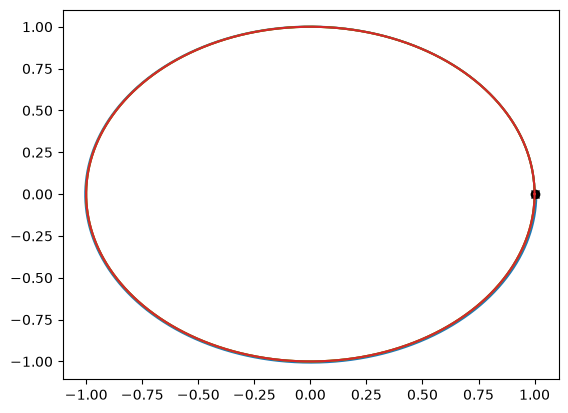

In [4]:
# Compute the orbit with different numbers of steps and methods to compare

for nsteps in np.array((10,100,1000,10000)):

    dt = 2 * np.pi / nsteps
    t = np.arange(nsteps+1)*dt
    x_start = np.array((1,0,0,1))
    x1 = euler(nsteps, dt, x_start, derivs_orbit)
    x2 = midpoint(nsteps, dt, x_start, derivs_orbit)
    x4 = rk4(nsteps, dt, x_start, derivs_orbit)

    print("nsteps = %d, err1 = %lg, err2 = %lg, err4 = %lg" % (nsteps, x1[-1,1], x2[-1,1], x4[-1,1]))
    
plt.plot(x1[:,0], x1[:,1])
plt.plot(x2[:,0], x2[:,1])
plt.plot(x4[:,0], x4[:,1])

plt.plot(x4[0,0],x4[0,1],'ko')
plt.plot(x4[-1,0],x4[-1,1],'kx')

result = scipy.integrate.solve_ivp(derivs_orbit, (0.0,2.0*np.pi), x_start, t_eval=t, atol=1e-6, rtol=1e-6)

x,y, vx, vy = result.y

print('scipy gives ', y[-1], ' with %d evaluations' % (result.nfev,))
plt.plot(x,y)
plt.show()

nsteps = 10, err4 = 0.104254
nsteps = 12, err4 = 0.0430479
nsteps = 15, err4 = 0.0148614
nsteps = 19, err4 = 0.00490612
nsteps = 25, err4 = 0.00138201
nsteps = 31, err4 = 0.000518955
nsteps = 39, err4 = 0.000184788
nsteps = 50, err4 = 6.13209e-05
nsteps = 63, err4 = 2.22674e-05
nsteps = 79, err4 = 8.35403e-06
nsteps = 100, err4 = 3.0433e-06
nsteps = 125, err4 = 1.18144e-06
nsteps = 158, err4 = 4.41478e-07
nsteps = 199, err4 = 1.68802e-07
nsteps = 251, err4 = 6.45979e-08
nsteps = 316, err4 = 2.50556e-08
nsteps = 398, err4 = 9.74852e-09
nsteps = 501, err4 = 3.81677e-09
nsteps = 630, err4 = 1.50564e-09
nsteps = 794, err4 = 5.90161e-10
nsteps = 1000, err4 = 2.32459e-10
nsteps = 1258, err4 = 9.2183e-11
nsteps = 1584, err4 = 3.64872e-11
nsteps = 1995, err4 = 1.43891e-11
nsteps = 2511, err4 = 5.73532e-12
nsteps = 3162, err4 = 2.29209e-12
nsteps = 3981, err4 = 8.93397e-13
nsteps = 5011, err4 = 2.91551e-13
nsteps = 6309, err4 = 1.18451e-13
nsteps = 7943, err4 = 1.10602e-13
nsteps = 10000, err4 

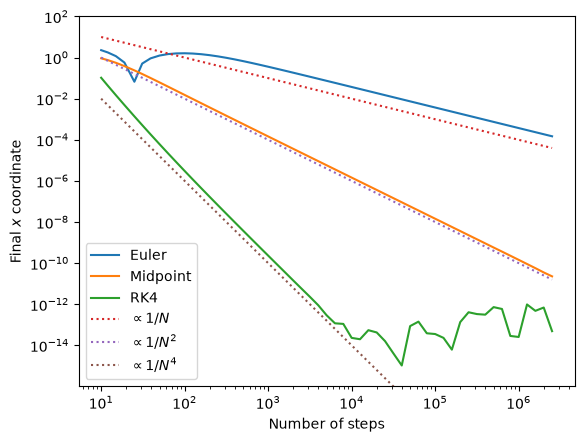

In [5]:
# Calculate the scaling with N

nvals = np.array([])
evals1 = np.array([])
evals2 = np.array([])
evals4 = np.array([])

for n in np.arange(1,6.5,0.1):

    nsteps = int(10**n)
    dt = 2 * np.pi / nsteps
    t = np.arange(nsteps+1)*dt
    x_start = np.array((1,0,0,1))
    x1 = euler(nsteps, dt, x_start, derivs_orbit)
    x2 = midpoint(nsteps, dt, x_start, derivs_orbit)
    x4 = rk4(nsteps, dt, x_start, derivs_orbit)

    print("nsteps = %d, err4 = %lg" % (nsteps, x4[-1,1]))
    nvals = np.append(nvals, nsteps)
    evals1 = np.append(evals1, abs(x1[-1,1]))
    evals2 = np.append(evals2, abs(x2[-1,1]))
    evals4 = np.append(evals4, abs(x4[-1,1]))

plt.plot(nvals, evals1, label='Euler')
plt.plot(nvals, evals2, label='Midpoint')
plt.plot(nvals, evals4, label='RK4')

plt.ylim((np.min(evals4)*0.1,100))

plt.plot(nvals, 100/nvals, ":", label = r'$\propto 1/N$')
plt.plot(nvals, 100/nvals**2, ":", label = r'$\propto 1/N^2$')
plt.plot(nvals, 100/nvals**4, ":", label = r'$\propto 1/N^4$')

plt.legend()
plt.yscale('log')
plt.xscale('log')
plt.ylabel(r'Final $x$ coordinate')
plt.xlabel(r'Number of steps')
plt.show()

The curves have the linear, quadratic and 4th order scaling we were expecting. The "dip" in the blue curve is a zero-crossing, which appears as a dip when we take the absolute value. Note also that the RK4 integrator is so good that we hit roundoff after $10^4$ steps.

## Implicit methods

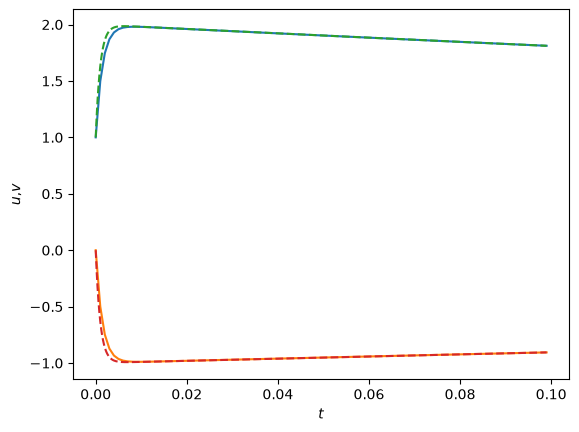

In [6]:
# The equations are linear with constant coefficients, so don't need
# to do a Newton solve
# We just need to specify the matrix of coefficients
C = np.array([[-998,-1998],[999,1999]])

h = 1e-3
nsteps = 100

x = np.zeros((nsteps,2))

# Explicit update
#A = np.identity(2) - h*C
# Implicit update
A = np.linalg.inv(np.identity(2) + h*C)

# Initial conditions
x[0,0] = 1
x[0,1] = 0

for i in range(1,nsteps):
    x[i] = A@x[i-1]
    
t = h * np.arange(nsteps)

plt.plot(t,x[:,0])
plt.plot(t,x[:,1])

# Plot the analytic solutions for comparison
t_anal = np.linspace(t[0], t[-1], 1000)
plt.plot(t_anal, 2*np.exp(-t_anal)-np.exp(-1000*t_anal),"--")
plt.plot(t_anal, -np.exp(-t_anal)+np.exp(-1000*t_anal),"--")

plt.xlabel(r'$t$')
plt.ylabel(r'$u$,$v$')

plt.show()